In [7]:
!pip install numpy; matplotlib; scipy; numba

Defaulting to user installation because normal site-packages is not writeable
  Using cached numba-0.65.1-cp313-cp313-win_amd64.whl.metadata (3.0 kB)
  Using cached llvmlite-0.47.0-cp313-cp313-win_amd64.whl.metadata (5.1 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.2 MB 17.5 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.2 MB 14.3 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 15.9 MB/s  0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   --- ------------------------------------ 2.9/36.5 MB 16.0 MB/s eta 0:00:03
   ------ --------------------------------- 6.3/36.5 MB 16.7 MB/s eta 0:00:02
   ---------- ----------------------------- 10.0/36.5 MB 16.9 MB/s eta 0:00:02
   -------------- ------------------------- 13.4/36.5 MB 17.0 MB/s eta 0:00:02
   ------------------ --------------------- 16.8/36.5 MB 17.0 MB/s eta 0:00:02
   ------------

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy.interpolate import CubicSpline
from scipy.interpolate import make_interp_spline
from numba import jit
from matplotlib.lines import Line2D
import scipy.integrate as sc
import pickle

In [ ]:
# @title Plotting/L2error
def get_L2(y):
  y = np.array(y)
  if y.ndim == 1:
      # For 1D arrays, calculate L2 norm over all elements
      L2 = np.sqrt(np.sum(y**2) / len(y))
  elif y.ndim == 2:
      # For 2D arrays, calculate L2 norm per row (e.g., per time step)
      # Divide by the number of elements in each row (spatial points)
      L2 = np.sqrt(np.sum(y**2, axis=1) / y.shape[1])
  else:
      raise ValueError("Input array y must be 1D or 2D for L2 norm calculation")
  return L2


def get_proper(a, b, x, r_join=2.01):
    scale = (1 + 1/(2*x))**2
    aa = scale * np.sqrt(a)
    R = x * scale * np.sqrt(b)

    idx = np.flatnonzero(R <= r_join)
    if idx.size == 0:
        raise ValueError(f"No points satisfy R <= {r_join}")

    j = idx[-1]   # last point on the left side of the join

    # Right branch: start exactly at the join
    x_right = x[j:]
    aa_right = aa[j:]
    R_right = R[j:]
    val_right = sc.cumulative_trapezoid(aa_right, x_right, initial=0)

    # Left branch: also start exactly at the same join, but integrate backwards
    x_left = x[:j+1][::-1]
    aa_left = aa[:j+1][::-1]
    R_left = R[:j+1][::-1]
    val_left = sc.cumulative_trapezoid(aa_left, x_left, initial=0)

    # Put left branch back into increasing x / R order
    R_left = R_left[::-1]
    val_left = val_left[::-1]

    # Remove only the duplicated join point from the left branch
    #(val_right, R_right), (val_left[:-1], R_left[:-1])
    np.concatenate((val_left[:-1], (val_right)))
    np.concatenate((R_left[:-1], (R_right)))

    return (np.concatenate((val_left[:-1], (val_right))), np.concatenate((R_left[:-1], (R_right))))


def load_simulation_data(filename):
  """Loads simulation data from a pickle file."""
  with open(filename, 'rb') as f:
    data_dict = pickle.load(f)
  print(f"Data loaded successfully from {filename}")
  return data_dict


In [ ]:
filename = 'log_endurance'

#grab all files

system_1 = load_simulation_data(f'{filename}_1.pkl')
system_2 = load_simulation_data(f'{filename}_2.pkl')
system_3 = load_simulation_data(f'{filename}_3.pkl')

#get a and b

a_1_list = [system_1['a3'],system_1['a4'],system_1['a5']]
b_1_list = [system_1['b3'],system_1['b4'],system_1['b5']]

a_2_list = [system_2['a3'],system_2['a4'],system_2['a5']]
b_2_list = [system_2['b3'],system_2['b4'],system_2['b5']]

l_2_list = [system_2['lap3'],system_2['lap4'],system_2['lap5']]

a_3_list = [system_3['a3'],system_3['a4'],system_3['a5']]
b_3_list = [system_3['b3'],system_3['b4'],system_3['b5']]

# constraints

m_1_list = [system_1['momentum3'],   system_1['momentum4'],   system_1['momentum5']]
h_1_list = [system_1['hamiltonian3'],system_1['hamiltonian4'],system_1['hamiltonian5']]

m_2_list = [system_2['momentum3'],   system_2['momentum4'],   system_2['momentum5']   ]
h_2_list = [system_2['hamiltonian3'],system_2['hamiltonian4'],system_2['hamiltonian5']]

m_3_list = [system_3['momentum3'],   system_3['momentum4'],   system_3['momentum5']]
h_3_list = [system_3['hamiltonian3'],system_3['hamiltonian4'],system_3['hamiltonian5']]

#get times
t_1_list = [system_1['times3'],system_1['times4'],system_1['times5']]
t_2_list = [system_2['times3'],system_2['times4'],system_2['times5']]
t_3_list = [system_3['times3'],system_3['times4'],system_3['times5']]

#get x
x_1_list = [system_1['x3'],system_1['x4'],system_1['x5']]
x_2_list = [system_2['x3'],system_2['x4'],system_2['x5']]
x_3_list = [system_3['x3'],system_3['x4'],system_3['x5']]

Data loaded successfully from log_G_endurance_1.pkl
Data loaded successfully from log_G_endurance_2.pkl
Data loaded successfully from log_G_endurance_3.pkl


need momentum and hamiltonian

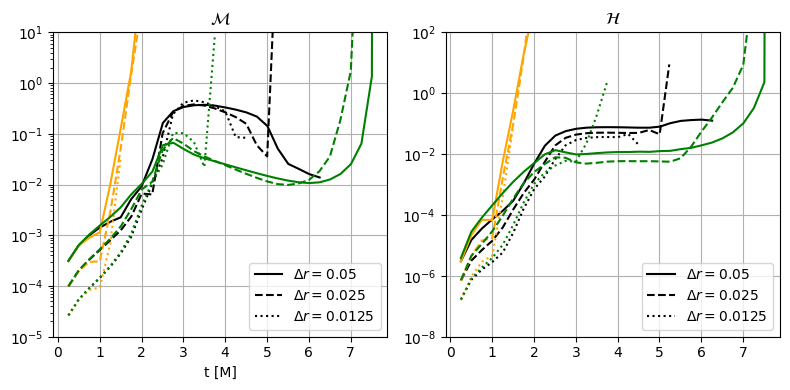

In [4]:
# @title Constraints over time
fig, ax = plt.subplots(1, 2, figsize = (8, 4))

num = -1
i = 0

styles = ['solid', 'dashed', 'dotted']

custom_lines = Line2D([0], [0], color = 'black', linestyle = 'solid')
custom_lines1 = Line2D([0], [0], color = 'black', linestyle = 'dashed')
custom_lines2 = Line2D([0], [0], color = 'black', linestyle = 'dotted')

for t, m in zip(t_1_list, m_1_list):
  ax[0].plot(t[1:],  get_L2(m)[1:], color = 'black', linestyle = styles[i])
  i += 1
i = 0


for t, m in zip(t_3_list, m_3_list):
  ax[0].plot(t[1:],  get_L2(m)[1:], color = 'orange', linestyle = styles[i])
  i += 1
i = 0

for t, m in zip(t_2_list, m_2_list):
  ax[0].plot(t[1:],  get_L2(m)[1:], color = 'green', linestyle = styles[i])
  i += 1
i = 0

for t, m in zip(t_1_list, h_1_list):
  ax[1].plot(t[1:],  get_L2(m)[1:], color = 'black', linestyle = styles[i])
  i += 1
i = 0


for t, m in zip(t_3_list, h_3_list):
  ax[1].plot(t[1:],  get_L2(m)[1:], color = 'orange', linestyle = styles[i])
  i += 1
i = 0

for t, m in zip(t_2_list, h_2_list):
  ax[1].plot(t[1:],  get_L2(m)[1:], color = 'green', linestyle = styles[i])
  i += 1
i = 0

ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[0].set_ylim(bottom = 10**(-5), top =10**(1))
ax[1].set_ylim(bottom = 10**(-8), top =10**(2))
#ax[0].set_xscale('log')
#ax[1].set_xscale('log')

ax[0].legend(handles = [custom_lines,custom_lines1,custom_lines2], labels =[r'$\Delta r= 0.05$',r'$\Delta r= 0.025$',r'$\Delta r= 0.0125$'], loc = 'lower right')
ax[1].legend(handles = [custom_lines,custom_lines1,custom_lines2], labels =[r'$\Delta r= 0.05$',r'$\Delta r= 0.025$',r'$\Delta r= 0.0125$'], loc = 'lower right')


ax[0].set_xlabel('t [M]')

ax[0].set_title(r'$\mathcal{M}$')
ax[1].set_title(r'$\mathcal{H}$')
ax[0].grid()
ax[1].grid()

#ax[0].set_xlim(0,200)

fig.tight_layout()
fig.savefig(f'{filename}_convergence.png')

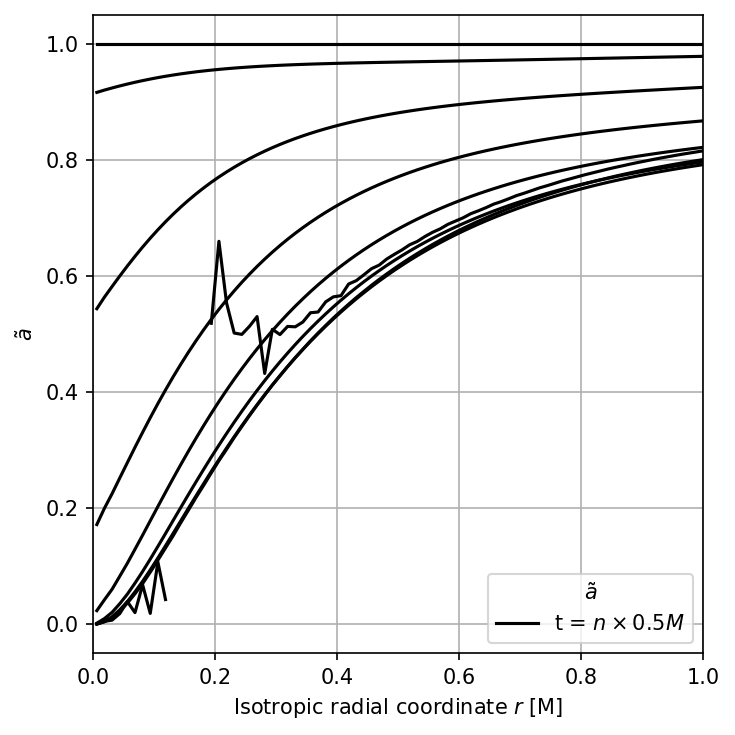

In [36]:
fig, ax = plt.subplots(1, figsize = (5, 5), dpi = 150)

num = -1
i = 0

styles = ['solid', 'dashed', 'dotted']

custom_lines = Line2D([0], [0], color = 'black', linestyle = 'solid')
custom_lines1 = Line2D([0], [0], color = 'black', linestyle = 'dashed')
custom_lines2 = Line2D([0], [0], color = 'black', linestyle = 'dotted')

x = x_2_list[2]
b = b_2_list[2]

for t in range(0,len(t_2_list[2]),2):
  ax.plot(x,b[t], color = 'black')



ax.legend(handles = [custom_lines,custom_lines1,custom_lines2], labels =[r'$\Delta r= 0.05$',r'$\Delta r= 0.025$',r'$\Delta r= 0.0125$'], loc = 'lower right')
custom_lines = [Line2D([0], [0], color = 'black', linestyle = 'solid')]

ax.legend(custom_lines, [r't = $n\times0.5M$'], title = r'$\tilde{a}$')

ax.set_xlabel(r'Isotropic radial coordinate $r$ [M]')
ax.set_xlim(0,1)
ax.set_ylabel(r'$\tilde{a}$')

ax.grid()

#ax[0].set_xlim(0,200)

fig.tight_layout()
fig.savefig(f'{filename}_a_b.png')

fig, ax = plt.subplots(1, figsize = (5, 5), dpi = 150)

num = -1
i = 0

styles = ['solid', 'dashed', 'dotted']

custom_lines = Line2D([0], [0], color = 'black', linestyle = 'solid')
custom_lines1 = Line2D([0], [0], color = 'black', linestyle = 'dashed')
custom_lines2 = Line2D([0], [0], color = 'black', linestyle = 'dotted')

x = x_2_list[2]
b = l_2_list[2]

for t in range(0,len(t_2_list[2]),2):
  ax.plot(x,b[t], color = 'black')



ax.legend(handles = [custom_lines,custom_lines1,custom_lines2], labels =[r'$\Delta r= 0.05$',r'$\Delta r= 0.025$',r'$\Delta r= 0.0125$'], loc = 'lower right')
custom_lines = [Line2D([0], [0], color = 'black', linestyle = 'solid')]

ax.legend(custom_lines, [r't = $n\times0.5M$'], title = r'$\tilde{a}$')

ax.set_xlabel(r'Isotropic radial coordinate $r$ [M]')
ax.set_xlim(0,1)
ax.set_ylabel(r'$\tilde{a}$')

ax.grid()

#ax[0].set_xlim(0,200)

fig.tight_layout()
fig.savefig(f'{filename}_lap.png')

needs b

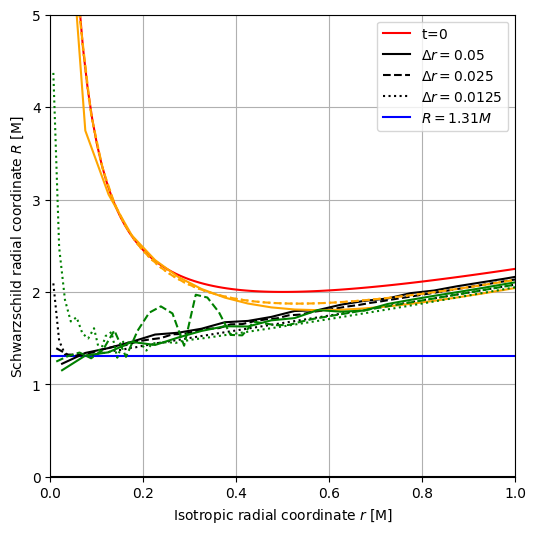

In [33]:
#@title coords plot

fig, ax = plt.subplots(1, figsize = (6,6))
x_c = np.linspace(0.01,100,10000)
blue = ax.axhline(y = 1.31, color = 'blue')
red, = ax.plot(x_c,np.sqrt(x_c*x_c* (1 + (1/(2*x_c)))**(4)), color = 'red', linestyle = 'solid', label = 't=0')
#
n = -2
i=0
for x, b in zip(x_1_list, b_1_list):
  ax.plot(x,np.sqrt(b[n]* x*x* (1 + (1/(2*x)))**(4)) , color = 'black', linestyle = styles[i])
  i += 1

i=0
for x, b in zip(x_3_list, b_3_list):
  ax.plot(x,np.sqrt(b[n]* x*x* (1 + (1/(2*x)))**(4)), color = 'orange', linestyle = styles[i])
  i += 1

i=0
for x, b in zip(x_2_list, b_2_list):
  ax.plot(x,np.sqrt(b[n]* x*x* (1 + (1/(2*x)))**(4)), color = 'green', linestyle = styles[i])
  i += 1

ax.axhline(y = 0, xmin=0, xmax = 10, color = 'black')
ax.set_ylim(bottom = 0, top = 5)
ax.set_xlim(0,1)
custom_lines = Line2D([0], [0], color = 'black', linestyle = 'solid')
custom_lines1 = Line2D([0], [0], color = 'black', linestyle = 'dashed')
custom_lines2 = Line2D([0], [0], color = 'black', linestyle = 'dotted')
ax.legend(handles = [red,custom_lines,custom_lines1,custom_lines2, blue], labels =[r't=$0$',r'$\Delta r= 0.05$',r'$\Delta r= 0.025$',r'$\Delta r= 0.0125$', r'$R = 1.31M$'])
ax.set_xlabel(r'Isotropic radial coordinate $r$ [M]')
ax.set_ylabel(r'Schwarzschild radial coordinate $R$ [M]')
ax.grid()

fig.savefig(f'{filename}_coordsfinal.png')

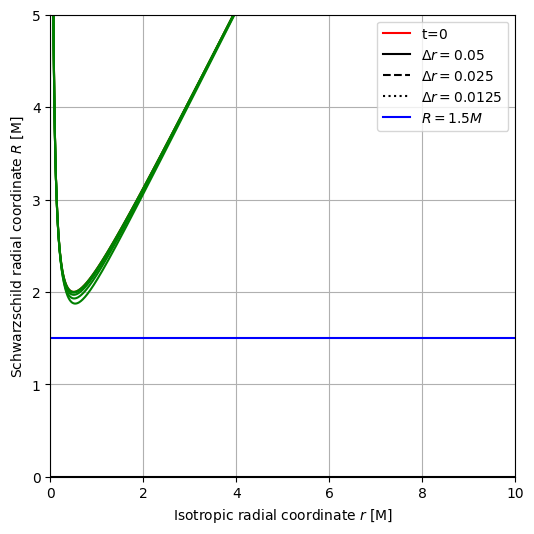

In [34]:
#@title coords plot

fig, ax = plt.subplots(1, figsize = (6,6))
x_c = np.linspace(0.01,100,10000)
blue = ax.axhline(y = 1.5, color = 'blue')
red, = ax.plot(x_c,np.sqrt(x_c*x_c* (1 + (1/(2*x_c)))**(4)), color = 'red', linestyle = 'solid', label = 't=0')
#
x = x_3_list[2]
b = b_3_list[2]


for t in range(0,len(t_3_list[2])-1):
  ax.plot(x,np.sqrt(b[t]* x*x* (1 + (1/(2*x)))**(4)), color = 'green')


ax.axhline(y = 0, xmin=0, xmax = 10, color = 'black')
ax.set_ylim(bottom = 0, top = 5)
ax.set_xlim(0,10)
custom_lines = Line2D([0], [0], color = 'black', linestyle = 'solid')
custom_lines1 = Line2D([0], [0], color = 'black', linestyle = 'dashed')
custom_lines2 = Line2D([0], [0], color = 'black', linestyle = 'dotted')
ax.legend(handles = [red,custom_lines,custom_lines1,custom_lines2, blue], labels =[r't=$0$',r'$\Delta r= 0.05$',r'$\Delta r= 0.025$',r'$\Delta r= 0.0125$', r'$R = 1.5M$'])
ax.set_xlabel(r'Isotropic radial coordinate $r$ [M]')
ax.set_ylabel(r'Schwarzschild radial coordinate $R$ [M]')
ax.grid()

#fig.savefig(f'{filename}_coords_system2.png')

Needs a

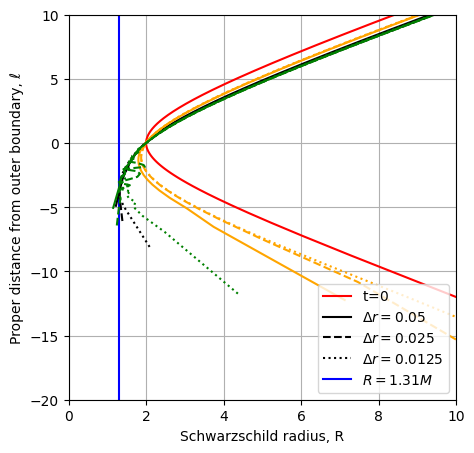

In [35]:

r = np.linspace(0.01,20,2000)
scale = (1+1/(2*r))**2
R = r*scale

min_point = r[R == np.min(R)]

val = sc.cumulative_trapezoid(scale[r>min_point],r[r>min_point],initial = 0)
val2 = sc.cumulative_trapezoid(np.flip(scale[r<min_point]),np.flip(r[r<min_point]),initial = 0)


n = -2

#original surface
fig, ax = plt.subplots(figsize=(5,5))
blue =ax.axvline(1.31, color = 'blue')
red, = ax.plot(R[r>min_point],val,color = 'red')
ax.plot(np.flip(R[r<min_point]),val2,color = 'red')
i=0
for x, a, b in zip(x_1_list, a_1_list, b_1_list):
  (right_val, right_R) = get_proper(a[n], b[n], x)
  ax.plot(right_R, right_val, color='black', linestyle = styles[i])
  i += 1


i=0
for x, a, b in zip(x_3_list, a_3_list, b_3_list):
  (right_val, right_R) = get_proper(a[n], b[n], x)
  ax.plot(right_R, right_val, color='orange', linestyle = styles[i])
  i += 1

i=0
for x, a, b in zip(x_2_list, a_2_list, b_2_list):
  (right_val, right_R) = get_proper(a[n], b[n], x)
  ax.plot(right_R, right_val, color='green', linestyle = styles[i])
  i += 1

ax.set_xlim(0.0,10)
ax.set_ylim(-20,10)
ax.set_ylabel("Proper distance from outer boundary, ℓ")
ax.set_xlabel("Schwarzschild radius, R")
#ax.set_title("Schwarzschild radius R vs proper distance from the horizon")


custom_lines = Line2D([0], [0], color = 'black', linestyle = 'solid')
custom_lines1 = Line2D([0], [0], color = 'black', linestyle = 'dashed')
custom_lines2 = Line2D([0], [0], color = 'black', linestyle = 'dotted')
ax.legend(handles = [red,custom_lines,custom_lines1,custom_lines2, blue], labels =[r't=$0$',r'$\Delta r= 0.05$',r'$\Delta r= 0.025$',r'$\Delta r= 0.0125$', r'$R = 1.31M$'], loc = 'lower right')
#ax.legend(handles = [red,custom_lines, blue], labels =[r't=$0$, Wormhole',r't = $50M$', r'R = 1.5M'], loc = 'lower right')
#ax.legend(handles = [red], labels =[r'Wormhole Topology'], loc = 'lower right')
ax.grid()
fig.savefig(f'{filename}_wormhole_final.png')
